# Unified Binary Classification Pipeline

This notebook consolidates the different approaches (standard ML, interpretable models, competitor benchmark) into a single pipeline with:
- 90/10 stratified train/test split
- GridSearchCV with cross-validation
- Confusion matrices and scoring
- Threshold tuning (PR-optimal and Youden's J)
- Best model & config summary per approach and per model type

## 1. Setup & Imports

In [1]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Suppress noisy sklearn convergence warnings during grid search
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

# Project imports
from src.models import (
    SKLEARN_MODELS_SEARCH_SPACE,
    INTERPRETABLE_MODELS_SEARCH_SPACE,
    RANDOM_STATE,
)
from src.utils import (
    load_metabric_data,
    prepare_data_splits_per_model,

)

from src.competitors import export_results

## 2. Load & Preprocess Data

In [3]:
_, df = load_metabric_data()
df.shape

Fetching METABRIC dataset from Kaggle...

Original dataset was loaded, shape: (1904, 693)
Original dataset was preprocessed, given a new shape: (679, 684)


(679, 684)

## 3. Define Feature-Space Experiments (Approaches)

Each approach defines a different feature space. The 90/10 stratified train/test split and the preprocessor are built per approach via `prepare_data_splits_per_model`.

In [ ]:
# Each experiment = (feature-space approach, dict of models to try)
EXPERIMENTS = [
    ("with_augmentation",  SKLEARN_MODELS_SEARCH_SPACE),
    # ("with_augmentation",  INTERPRETABLE_MODELS_SEARCH_SPACE),
    ("pure_numerical",     SKLEARN_MODELS_SEARCH_SPACE),
    # ("pure_numerical",     INTERPRETABLE_MODELS_SEARCH_SPACE),
    ("rezaeian",           SKLEARN_MODELS_SEARCH_SPACE),
    # ("rezaeian",     INTERPRETABLE_MODELS_SEARCH_SPACE),
    ("kurniadi",           SKLEARN_MODELS_SEARCH_SPACE),
    # ("kurniadi",     INTERPRETABLE_MODELS_SEARCH_SPACE),
]

## 4. Define Scoring & Helper Functions

In [5]:
SCORING = {
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy',
    'average_precision': 'average_precision',
    'f1': 'f1',
}

REFIT_METRIC = 'roc_auc'  # TODO: change if you prefer another refit metricCV_FOLDS = 5              # TODO: adjust number of CV folds if needed

In [6]:
def make_full_pipeline(preprocessor, classifier):
    """Combine the preprocessing pipeline with a classifier step."""
    return Pipeline([
        *preprocessor.steps,
        ('classifier', classifier),
    ])


def evaluate_at_threshold(y_true, proba, threshold):
    """Return predictions and key metrics at a given threshold."""
    preds = (proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'f1': f1_score(y_true, preds),
        'balanced_acc': balanced_accuracy_score(y_true, preds),
        'roc_auc': roc_auc_score(y_true, preds),
        'predictions': preds,
    }


def find_best_threshold_pr(y_true, proba):
    """Find threshold maximizing F1 on the precision-recall curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = int(np.argmax(f1_scores))
    return thresholds[min(best_idx, len(thresholds) - 1)]


def find_best_threshold_youden(y_true, proba):
    """Find threshold maximizing Youden's J statistic on the ROC curve."""
    fpr, tpr, thresholds = roc_curve(y_true, proba)
    j_scores = tpr - fpr
    return thresholds[int(np.argmax(j_scores))]


def plot_confusion_matrix(y_true, preds, title=''):
    """Display confusion matrix."""
    ConfusionMatrixDisplay.from_predictions(y_true, preds, cmap='Blues')
    plt.title(title)
    plt.show()

## 5. Run All Experiments

Outer loop: **feature-space approach** (e.g. `with_augmentation`, `pure_numerical`, `rezaeian`, `kurniadi`).  
Inner loop: **models** from the corresponding model registry.

In [7]:
from copy import deepcopy

CV_FOLDS = 3

results = []  # one dict per (approach, model_family, model)

for approach, model_registry in EXPERIMENTS:
    # Determine a readable model-family label
    if model_registry is SKLEARN_MODELS_SEARCH_SPACE:
        model_family = "Standard ML"
    elif model_registry is INTERPRETABLE_MODELS_SEARCH_SPACE:
        model_family = "Interpretable"
    else:
        model_family = "Custom"

    print(f"\n{'='*70}")
    print(f"  Approach: {approach}  |  Models: {model_family}")
    print(f"{'='*70}")

    # Build data split + preprocessor for this feature space
    X_train, X_test, y_train, y_test, preprocessor_builder = \
        prepare_data_splits_per_model(approach=approach, df=df)

    preprocess_pipeline = preprocessor_builder(X_train)

    for model_name, (estimator, param_grid) in model_registry.items():
        print(f"\n--- {model_name} ---")

        # Build full pipeline: preprocessor steps + classifier
        pipe = Pipeline([
            *preprocess_pipeline.steps,
            ('classifier', deepcopy(estimator)),
        ])

        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=CV_FOLDS,
            scoring=SCORING,
            refit=REFIT_METRIC,
            n_jobs=-1,
            error_score=np.nan,
        )

        try:
            grid.fit(X_train, y_train)
        except Exception as e:
            print(f"  [SKIP] {model_name} failed: {e}")
            continue

        proba = grid.predict_proba(X_test)[:, 1]

        # CV scores (from the best index chosen by REFIT_METRIC)
        best_idx = grid.best_index_
        cv_auc = grid.best_score_
        cv_bal_acc = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
        cv_ap = grid.cv_results_['mean_test_average_precision'][best_idx]
        cv_f1 = grid.cv_results_['mean_test_f1'][best_idx]

        # Test scores at default threshold
        y_pred_default = grid.predict(X_test)
        test_auc = roc_auc_score(y_test, proba)
        test_ap = average_precision_score(y_test, proba)
        test_bal_acc = balanced_accuracy_score(y_test, y_pred_default)
        test_f1 = f1_score(y_test, y_pred_default)

        print(
            f"  CV AUC={cv_auc:.3f}  CV AP={cv_ap:.3f}  CV F1={cv_f1:.3f}  CV BalAcc={cv_bal_acc:.3f} | "
            f"Test AUC={test_auc:.3f}  Test AP={test_ap:.3f}  Test F1={test_f1:.3f}  Test BalAcc={test_bal_acc:.3f}"
        )

        results.append({
            'feature_space': approach,
            'model_family': model_family,
            'model': model_name,
            'best_params': grid.best_params_,
            'cv_auc': cv_auc,
            'cv_ap': cv_ap,
            'cv_f1': cv_f1,
            'cv_bal_acc': cv_bal_acc,
            'test_auc': test_auc,
            'test_ap': test_ap,
            'test_f1': test_f1,
            'test_bal_acc': test_bal_acc,
            'proba': proba,
            'y_test': y_test,
            'X_test': X_test,        
            'grid': grid,
        })

print(f"\n\nFinished: {len(results)} model runs collected.")


  Approach: pure_numerical  |  Models: Standard ML
Train: (611, 498), Test: (68, 498)
Train target distribution:
target_mortality
0    480
1    131
Name: count, dtype: int64
Test  target distribution:
target_mortality
0    53
1    15
Name: count, dtype: int64
Missing columns report: 
 cellularity                    7
neoplasm_histologic_grade     28
mutation_count                 7
tumor_size                     1
tumor_stage                  143
dtype: int64

--- Logistic Regression ---
  CV AUC=0.662  CV AP=0.363  CV F1=0.140  CV BalAcc=0.529 | Test AUC=0.668  Test AP=0.449  Test F1=0.125  Test BalAcc=0.533

--- Random Forest ---
  CV AUC=0.680  CV AP=0.365  CV F1=0.000  CV BalAcc=0.500 | Test AUC=0.757  Test AP=0.480  Test F1=0.000  Test BalAcc=0.500

--- SVM ---
  CV AUC=0.671  CV AP=0.372  CV F1=0.000  CV BalAcc=0.500 | Test AUC=0.614  Test AP=0.405  Test F1=0.000  Test BalAcc=0.500

  Approach: pure_numerical  |  Models: Interpretable
Train: (611, 498), Test: (68, 498)
Train tar

KeyboardInterrupt: 

## 6. Confusion Matrices (Default Threshold = 0.5)

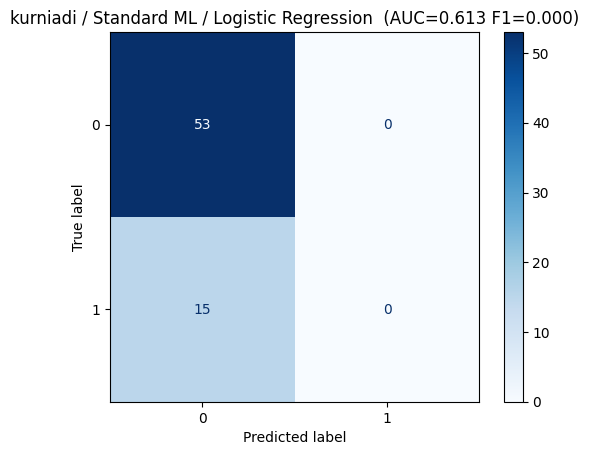

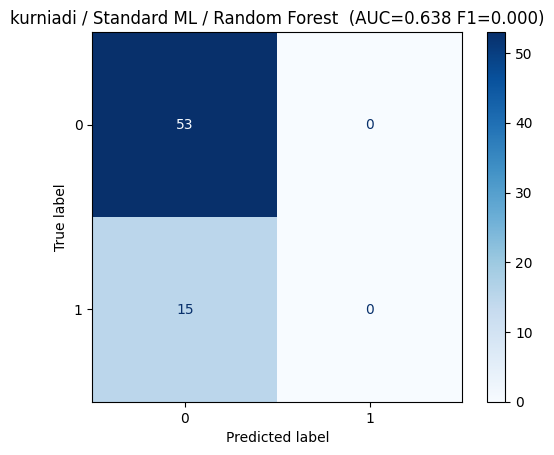

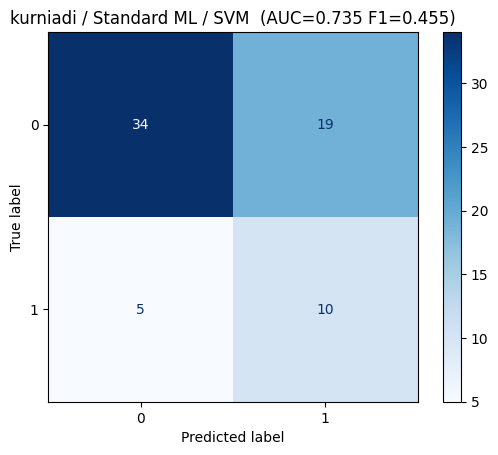

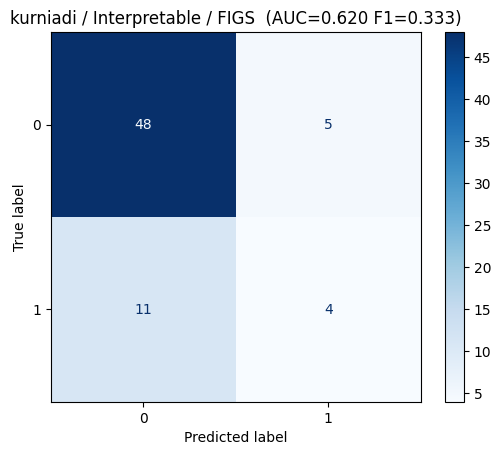

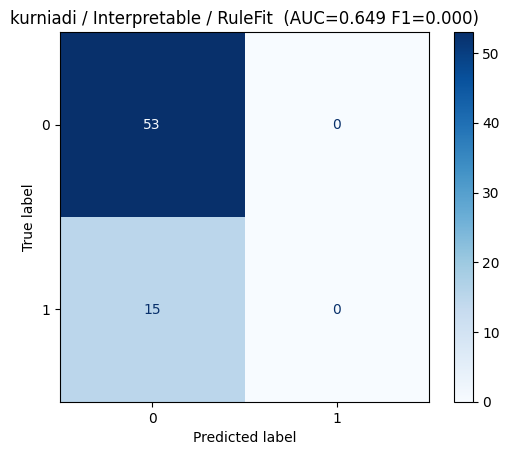

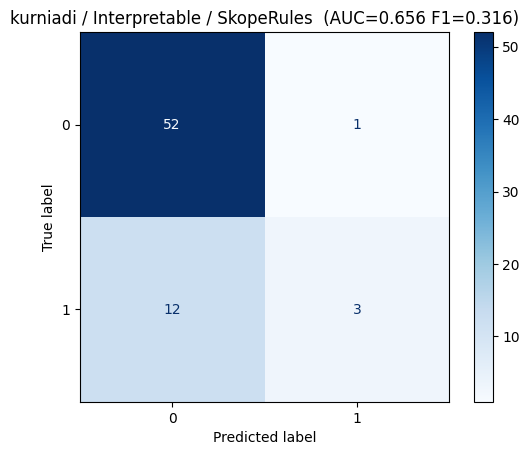

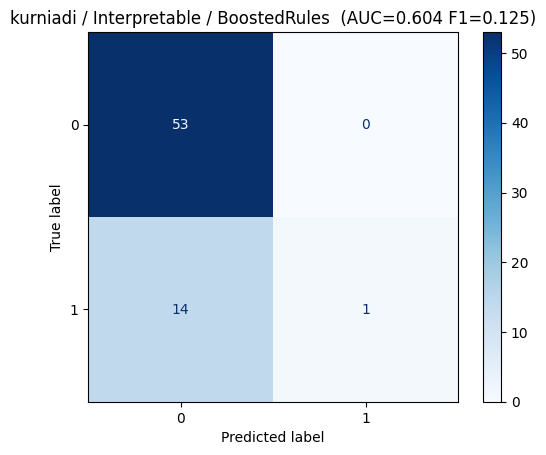

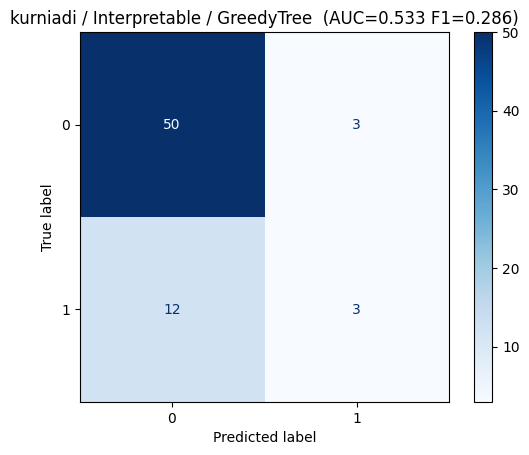

In [ ]:
for r in results:
    preds = r['grid'].predict(r['X_test'])
    title = f"{r['feature_space']} / {r['model_family']} / {r['model']}  (AUC={r['test_auc']:.3f} F1={r['test_f1']:.3f})"
    plot_confusion_matrix(r['y_test'], preds, title=title)

## 7. Threshold Tuning

For each trained model we compute:
- **PR-optimal** threshold (maximizes F1)
- **Youden's J** threshold (maximizes TPR − FPR)

In [ ]:
tuned_rows = []

for r in results:
    proba = r['proba']
    y_t = r['y_test']

    # PR-optimal threshold
    thr_pr = find_best_threshold_pr(y_t, proba)
    eval_pr = evaluate_at_threshold(y_t, proba, thr_pr)

    # Youden's J threshold
    thr_j = find_best_threshold_youden(y_t, proba)
    eval_j = evaluate_at_threshold(y_t, proba, thr_j)

    tuned_rows.append({
        'feature_space': r['feature_space'],
        'model_family': r['model_family'],
        'model': r['model'],
        'default_f1': r['test_f1'],
        'pr_threshold': thr_pr,
        'pr_f1': eval_pr['f1'],
        'pr_bal_acc': eval_pr['balanced_acc'],
        'youden_threshold': thr_j,
        'youden_f1': eval_j['f1'],
        'youden_bal_acc': eval_j['balanced_acc'],
    })

df_tuned = pd.DataFrame(tuned_rows)
df_tuned = df_tuned.round(3)
df_tuned

,feature_space,model_family,model,default_f1,pr_threshold,pr_f1,pr_bal_acc,youden_threshold,youden_f1,youden_bal_acc
0,kurniadi,Standard ML,Logistic Regression,0.000,0.182,0.448,0.650,0.182,0.448,0.650
1,kurniadi,Standard ML,Random Forest,0.000,0.167,0.424,0.618,0.259,0.412,0.620
2,kurniadi,Standard ML,SVM,0.455,0.206,0.522,0.721,0.198,0.520,0.726
3,kurniadi,Interpretable,FIGS,0.333,0.384,0.432,0.635,0.384,0.432,0.635
4,kurniadi,Interpretable,RuleFit,0.000,0.031,0.453,0.655,0.031,0.453,0.655
5,kurniadi,Interpretable,SkopeRules,0.316,0.287,0.462,0.653,0.287,0.462,0.653
6,kurniadi,Interpretable,BoostedRules,0.125,0.198,0.388,0.565,0.393,0.381,0.614
7,kurniadi,Interpretable,GreedyTree,0.286,0.040,0.377,0.547,0.611,0.286,0.572


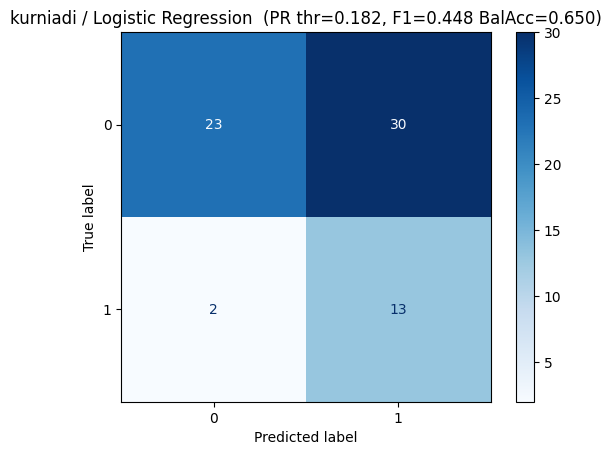

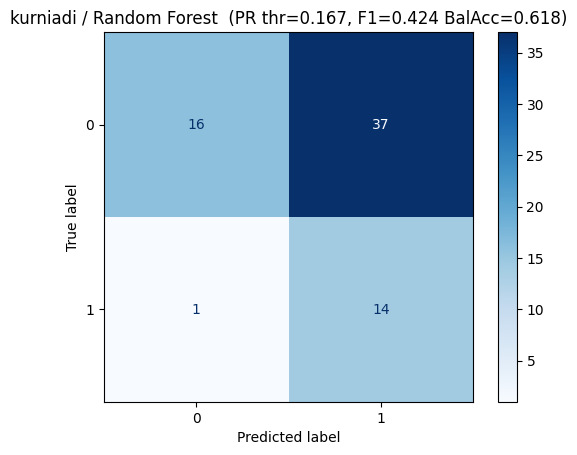

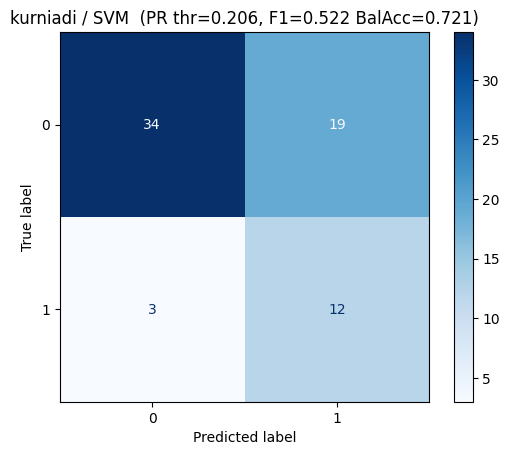

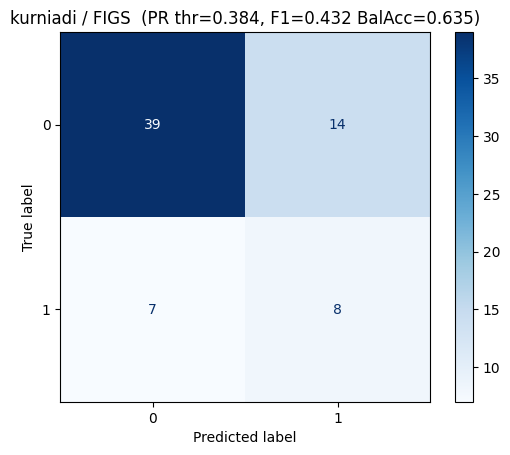

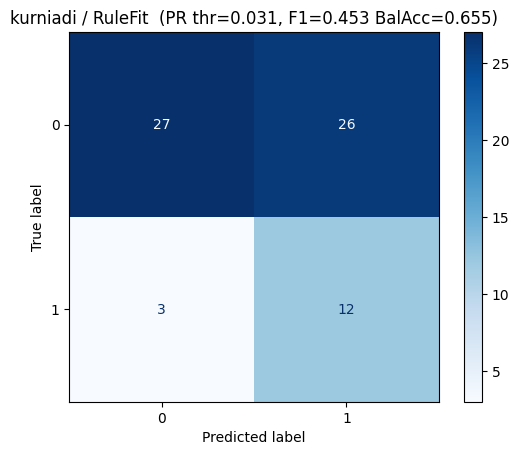

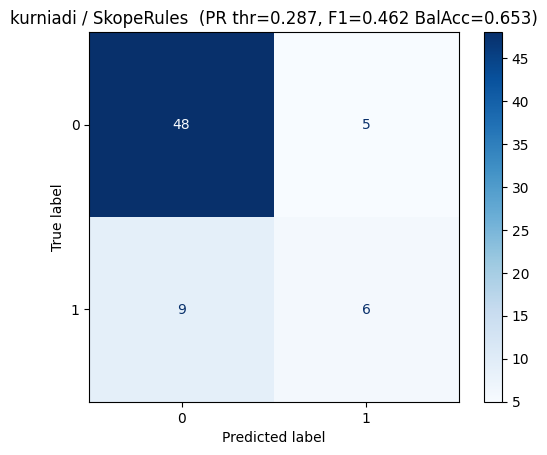

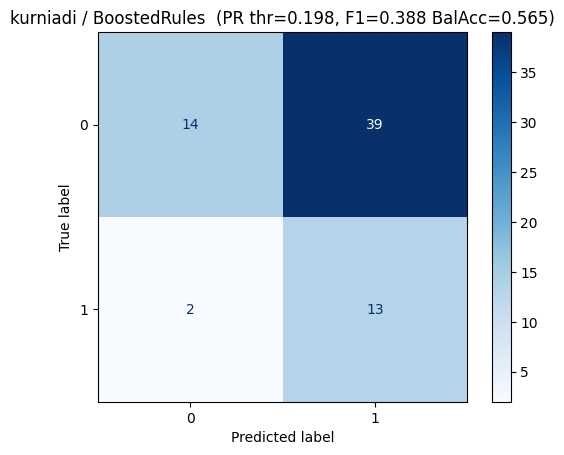

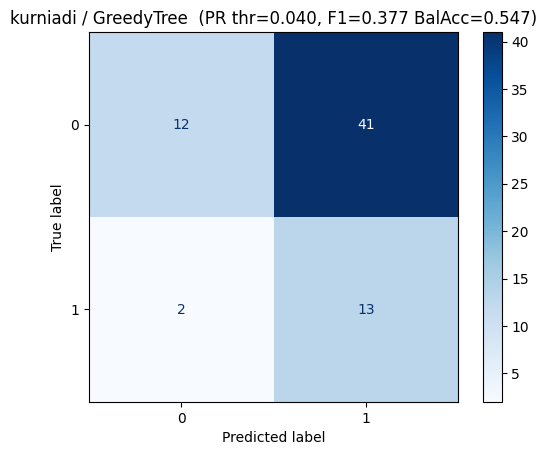

In [ ]:
# Confusion matrices with the PR-tuned threshold
for r, row in zip(results, tuned_rows):
    preds = (r['proba'] >= row['pr_threshold']).astype(int)
    title = (
        f"{r['feature_space']} / {r['model']}  "
        f"(PR thr={row['pr_threshold']:.3f}, F1={row['pr_f1']:.3f} BalAcc={row['pr_bal_acc']:.3f})"
    )
    plot_confusion_matrix(r['y_test'], preds, title=title)

## 8. Summary: Best Model per Feature-Space Approach

In [ ]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('proba', 'grid', 'y_test', 'X_test')}
    for r in results
])

# Round numeric columns to 3 decimals
numeric_cols = df_results.select_dtypes(include='number').columns
df_results[numeric_cols] = df_results[numeric_cols].round(3)

# Best model per feature-space approach (by test AUC)
best_per_approach = df_results.loc[
    df_results.groupby('model_family')['test_auc'].idxmax(),
    ['feature_space', 'model_family', 'model', 'test_auc', 'test_ap', 'test_f1', 'test_bal_acc', 'best_params']
]

display(best_per_approach)

print("Best model per feature-space approach (by Test AUC):")

,feature_space,model_family,model,test_auc,test_ap,test_f1,test_bal_acc,best_params
5,kurniadi,Interpretable,SkopeRules,0.656,0.385,0.316,0.591,"{'classifier__max_depth': 2, 'classifier__n_es..."
2,kurniadi,Standard ML,SVM,0.735,0.516,0.455,0.654,"{'classifier__C': 0.1, 'classifier__class_weig..."


Best model per feature-space approach (by Test AUC):


## 9. Full Leaderboard

In [ ]:
df_results.sort_values('test_auc', ascending=False)[
    ['feature_space', 'model_family', 'model',
     'cv_auc', 'cv_ap', 'cv_f1', 'cv_bal_acc',

     'test_auc', 'test_ap', 'test_f1', 'test_bal_acc']]

,feature_space,model_family,model,cv_auc,cv_ap,cv_f1,cv_bal_acc,test_auc,test_ap,test_f1,test_bal_acc
2,kurniadi,Standard ML,SVM,0.585,0.281,0.372,0.581,0.735,0.516,0.455,0.654
5,kurniadi,Interpretable,SkopeRules,NaN,NaN,0.080,0.511,0.656,0.385,0.316,0.591
4,kurniadi,Interpretable,RuleFit,0.607,0.316,0.000,0.500,0.649,0.368,0.000,0.500
1,kurniadi,Standard ML,Random Forest,0.596,0.306,0.000,0.500,0.638,0.341,0.000,0.500
3,kurniadi,Interpretable,FIGS,0.569,0.281,0.167,0.525,0.620,0.360,0.333,0.586
0,kurniadi,Standard ML,Logistic Regression,0.607,0.309,0.000,0.498,0.613,0.330,0.000,0.500
6,kurniadi,Interpretable,BoostedRules,0.564,0.285,0.000,0.500,0.604,0.392,0.125,0.533
7,kurniadi,Interpretable,GreedyTree,0.569,0.255,0.160,0.510,0.533,0.306,0.286,0.572


## 10. Export Best Config per Experiment

In [ ]:
# Best config per experiment = best model within each (feature_space, model_family) combo
best_per_experiment = df_results.loc[
    df_results.groupby(['feature_space', 'model_family'])['test_auc'].idxmax()
].sort_values('test_auc', ascending=False)

# Merge PR-tuned threshold and metrics from df_tuned
best_export = best_per_experiment.merge(
    df_tuned[['feature_space', 'model_family', 'model',
              'pr_threshold', 'pr_f1', 'pr_bal_acc']],
    on=['feature_space', 'model_family', 'model'],
    how='left',
)

# Use default threshold (0.5) when PR threshold is missing/NaN
best_export['threshold'] = best_export['pr_threshold'].fillna(0.5)
best_export['tuned_f1'] = best_export['pr_f1'].fillna(best_export['test_f1'])
best_export['tuned_bal_acc'] = best_export['pr_bal_acc'].fillna(best_export['test_bal_acc'])
best_export = best_export.drop(columns=['pr_threshold', 'pr_f1', 'pr_bal_acc'])

display(best_export[[
    'feature_space', 'model_family', 'model',
    'threshold', 'tuned_f1', 'tuned_bal_acc',
    'cv_auc', 'cv_ap', 'cv_f1', 'cv_bal_acc',
    'test_auc', 'test_ap', 'test_f1', 'test_bal_acc',
    'best_params',
]].round(3))

# Export to CSV
best_export.to_csv('../data/best_config_per_experiment.csv', index=False)
print("Exported to data/best_config_per_experiment.csv")

,feature_space,model_family,model,threshold,tuned_f1,tuned_bal_acc,cv_auc,cv_ap,cv_f1,cv_bal_acc,test_auc,test_ap,test_f1,test_bal_acc,best_params
0,kurniadi,Standard ML,SVM,0.206,0.522,0.721,0.585,0.281,0.372,0.581,0.735,0.516,0.455,0.654,"{'classifier__C': 0.1, 'classifier__class_weig..."
1,kurniadi,Interpretable,SkopeRules,0.287,0.462,0.653,NaN,NaN,0.080,0.511,0.656,0.385,0.316,0.591,"{'classifier__max_depth': 2, 'classifier__n_es..."


Exported to data/best_config_per_experiment.csv


## 11. Full Tuned-Threshold Results (All Models)

In [ ]:
# Merge tuned thresholds into the full results table
df_all_tuned = df_results.merge(
    df_tuned[['feature_space', 'model_family', 'model',
              'pr_threshold', 'pr_f1', 'pr_bal_acc',
              'youden_threshold', 'youden_f1', 'youden_bal_acc']],
    on=['feature_space', 'model_family', 'model'],
    how='left',
)

df_all_tuned.sort_values('test_auc', ascending=False)[[
    'feature_space', 'model_family', 'model',
    'test_auc', 'test_ap', 'test_f1', 'test_bal_acc',
    'pr_threshold', 'pr_f1', 'pr_bal_acc',
    'youden_threshold', 'youden_f1', 'youden_bal_acc',
]].round(3)

,feature_space,model_family,model,test_auc,test_ap,test_f1,test_bal_acc,pr_threshold,pr_f1,pr_bal_acc,youden_threshold,youden_f1,youden_bal_acc
2,kurniadi,Standard ML,SVM,0.735,0.516,0.455,0.654,0.206,0.522,0.721,0.198,0.520,0.726
5,kurniadi,Interpretable,SkopeRules,0.656,0.385,0.316,0.591,0.287,0.462,0.653,0.287,0.462,0.653
4,kurniadi,Interpretable,RuleFit,0.649,0.368,0.000,0.500,0.031,0.453,0.655,0.031,0.453,0.655
1,kurniadi,Standard ML,Random Forest,0.638,0.341,0.000,0.500,0.167,0.424,0.618,0.259,0.412,0.620
3,kurniadi,Interpretable,FIGS,0.620,0.360,0.333,0.586,0.384,0.432,0.635,0.384,0.432,0.635
0,kurniadi,Standard ML,Logistic Regression,0.613,0.330,0.000,0.500,0.182,0.448,0.650,0.182,0.448,0.650
6,kurniadi,Interpretable,BoostedRules,0.604,0.392,0.125,0.533,0.198,0.388,0.565,0.393,0.381,0.614
7,kurniadi,Interpretable,GreedyTree,0.533,0.306,0.286,0.572,0.040,0.377,0.547,0.611,0.286,0.572


## 12. Refit & Score Best Model per Experiment

Extract the winning model config from each experiment, refit on the full training set, and produce detailed test-set scoring at both the default (0.5) and PR-tuned thresholds.

In [ ]:
# Build a lookup from (feature_space, model_family, model) -> results entry
results_lookup = {
    (r['feature_space'], r['model_family'], r['model']): r
    for r in results
}

best_model_reports = []

for _, row in best_per_experiment.iterrows():
    key = (row['feature_space'], row['model_family'], row['model'])
    r = results_lookup[key]

    # The grid already contains the best estimator fitted on X_train
    best_pipeline = r['grid'].best_estimator_
    X_test_exp = r['X_test']
    y_test_exp = r['y_test']

    # Predict probabilities and default predictions
    proba = best_pipeline.predict_proba(X_test_exp)[:, 1]
    y_pred_default = best_pipeline.predict(X_test_exp)

    # PR-tuned threshold
    thr_pr = find_best_threshold_pr(y_test_exp, proba)
    y_pred_tuned = (proba >= thr_pr).astype(int)

    # Scores at default threshold (0.5)
    default_scores = {
        'auc': roc_auc_score(y_test_exp, proba),
        'ap': average_precision_score(y_test_exp, proba),
        'f1': f1_score(y_test_exp, y_pred_default),
        'bal_acc': balanced_accuracy_score(y_test_exp, y_pred_default),
    }

    # Scores at PR-tuned threshold
    tuned_scores = {
        'auc': default_scores['auc'],  # AUC is threshold-independent
        'ap': default_scores['ap'],    # AP is threshold-independent
        'f1': f1_score(y_test_exp, y_pred_tuned),
        'bal_acc': balanced_accuracy_score(y_test_exp, y_pred_tuned),
    }

    best_model_reports.append({
        'feature_space': row['feature_space'],
        'model_family': row['model_family'],
        'model': row['model'],
        'best_params': row['best_params'],
        'default_f1': default_scores['f1'],
        'default_bal_acc': default_scores['bal_acc'],
        'pr_threshold': thr_pr,
        'tuned_f1': tuned_scores['f1'],
        'tuned_bal_acc': tuned_scores['bal_acc'],
        'test_auc': default_scores['auc'],
        'test_ap': default_scores['ap'],
    })

    # Print classification report per best model
    print(f"\n{'='*70}")
    print(f"  {row['feature_space']} / {row['model_family']} / {row['model']}")
    print(f"  PR-tuned threshold: {thr_pr:.3f}")
    print(f"{'='*70}")
    print("\n--- Default threshold (0.5) ---")
    print(classification_report(y_test_exp, y_pred_default, digits=3))
    print(f"--- PR-tuned threshold ({thr_pr:.3f}) ---")
    print(classification_report(y_test_exp, y_pred_tuned, digits=3))

df_best_models = pd.DataFrame(best_model_reports).round(3)
df_best_models


  kurniadi / Standard ML / SVM
  PR-tuned threshold: 0.206

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0      0.872     0.642     0.739        53
           1      0.345     0.667     0.455        15

    accuracy                          0.647        68
   macro avg      0.608     0.654     0.597        68
weighted avg      0.756     0.647     0.676        68

--- PR-tuned threshold (0.206) ---
              precision    recall  f1-score   support

           0      0.919     0.642     0.756        53
           1      0.387     0.800     0.522        15

    accuracy                          0.676        68
   macro avg      0.653     0.721     0.639        68
weighted avg      0.802     0.676     0.704        68


  kurniadi / Interpretable / SkopeRules
  PR-tuned threshold: 0.287

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0      0.812     0.981     0.889        53
       

,feature_space,model_family,model,best_params,default_f1,default_bal_acc,pr_threshold,tuned_f1,tuned_bal_acc,test_auc,test_ap
0,kurniadi,Standard ML,SVM,"{'classifier__C': 0.1, 'classifier__class_weig...",0.455,0.654,0.206,0.522,0.721,0.735,0.516
1,kurniadi,Interpretable,SkopeRules,"{'classifier__max_depth': 2, 'classifier__n_es...",0.316,0.591,0.287,0.462,0.653,0.656,0.385
